In [35]:
library(tidyverse)
library(ComplexHeatmap)
library(circlize)
library(psych)
library(pheatmap)
library(RColorBrewer)
library(patchwork)
library(ggsignif)

In [36]:
# 1. LOAD DATA
master_df <- read.csv("/home/mjehangir/telomere-sv-analysis/data/BND_subtype_final_master_data.csv", header = TRUE, sep = ",", stringsAsFactors = FALSE)

In [37]:
# --- FIGURE: CHROMOTHRIPSIS DISTRIBUTION ---
df_counts <- tibble(
  Grade = c("Grade 2", "Grade 3"),
  `Non-Chromothripsis` = c(5, 3),
  Chromothripsis = c(1, 6)
)

In [38]:
df_long_grade <- df_counts %>%
  pivot_longer(cols = -Grade, names_to = "Status", values_to = "Count") %>%
  mutate(Grade = factor(Grade, levels = c("Grade 2", "Grade 3")),
         Status = factor(Status, levels = c("Non-Chromothripsis", "Chromothripsis")))

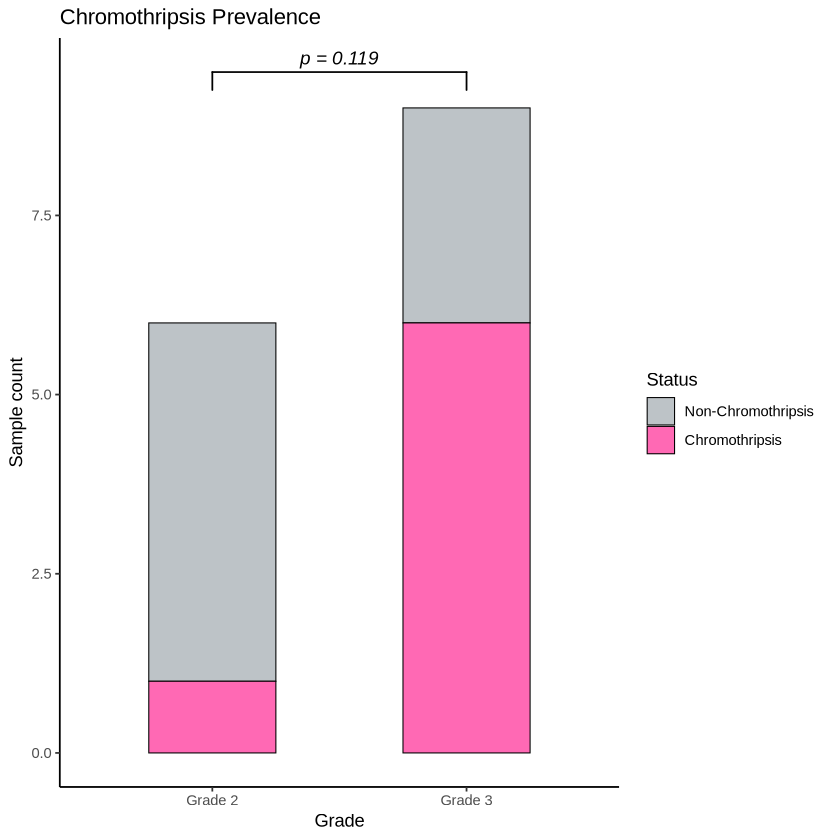

In [39]:
p <- ggplot(df_long_grade, aes(x = Grade, y = Count, fill = Status)) +
  geom_col(color = "black", width = 0.5, linewidth = 0.3) + 
  geom_signif(y_position = 9.5, xmin = 1, xmax = 2,
              annotation = paste0("p = ", round(p_val, 3)), 
              tip_length = 0.05, textsize = 4, fontface = "italic") +
  scale_fill_manual(values = c("Non-Chromothripsis" = "#BDC3C7", "Chromothripsis" = "hotpink")) +
  theme_classic() +
  labs(title = "Chromothripsis Prevalence", y = "Sample count")
p

In [40]:
# Save plot 'p'
ggsave(filename = "/home/mjehangir/telomere-sv-analysis/plots/fig2/Chromothripsis_Distribution.pdf", 
       plot = p, width = 5, height = 4, device = "pdf")

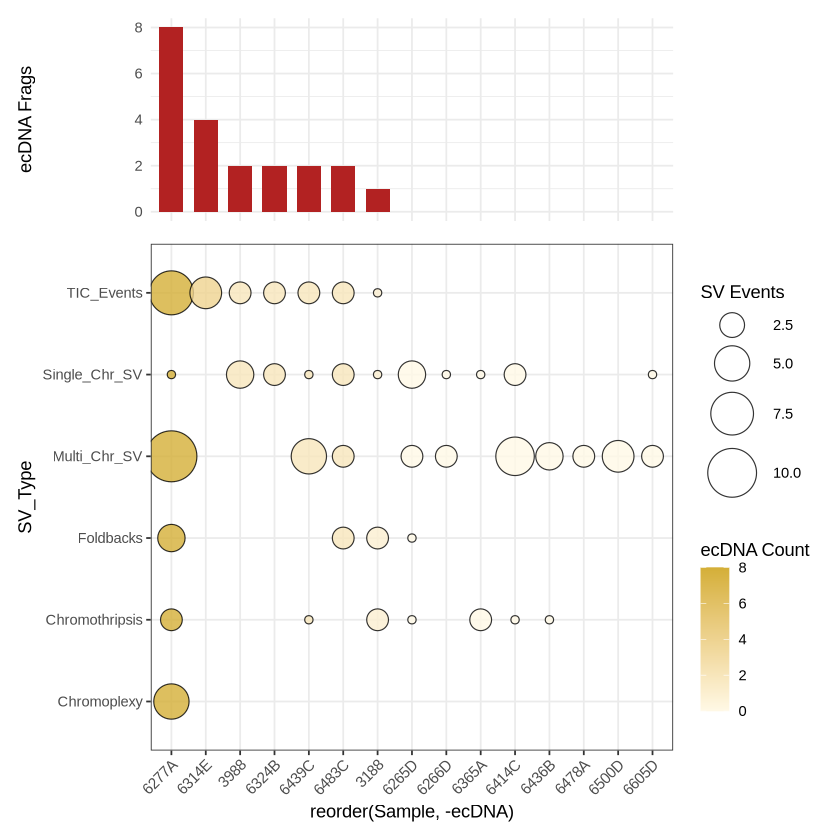

In [41]:
# --- FIGURE 2: BUBBLE PLOT ---

df_bubbles <- master_df %>%
  rename(Sample = Samples) %>% 
  select(Sample, ecDNA = TICs, TIC_Events = TICs, Chromothripsis, 
         Foldbacks = Foldback, Single_Chr_SV = Single.Chr, 
         Multi_Chr_SV = Multi.Chr, Chromoplexy) %>%
  pivot_longer(cols = -c(Sample, ecDNA), names_to = "SV_Type", values_to = "Event_Count")

p_top <- ggplot(master_df %>% rename(Sample = Samples), aes(x = reorder(Sample, -TICs), y = TICs)) +
  geom_bar(stat = "identity", fill = "firebrick", width = 0.7) +
  theme_minimal() + labs(y = "ecDNA Frags") +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank())

p_bottom <- ggplot(df_bubbles, aes(x = reorder(Sample, -ecDNA), y = SV_Type)) +
  geom_point(data = subset(df_bubbles, Event_Count > 0), 
             aes(size = Event_Count, fill = ecDNA), shape = 21, alpha = 0.8) +
  scale_size_continuous(range = c(2, 14), name = "SV Events") + 
  scale_fill_gradient(low = "#FFF9E6", high = "#D4AF37", name = "ecDNA Count") + 
  theme_bw() + theme(axis.text.x = element_text(angle = 45, hjust = 1))

combined_plot <- (p_top / p_bottom) + plot_layout(heights = c(1, 2.5))
combined_plot